# Examen Parcial 1 - Machine Learning I


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Configuración
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("="*80)
print("📊 PREDICCIÓN DE APROBACIÓN - Electricidad y Magnetismo")
print("🤖 REGRESIÓN LOGÍSTICA")
print("="*80)

# =============================================================================
# 1. CARGAR DATOS
# =============================================================================
print("\n📂 Cargando datos concatenados...")
try:
    df =pd.read_csv(r'datos_concatenados.csv')

    print(f"✅ Datos cargados: {len(df):,} registros")
except FileNotFoundError:
    print("❌ No se encontró el archivo 'datosConcatenados.csv'")
    exit()

📊 PREDICCIÓN DE APROBACIÓN - Electricidad y Magnetismo
🤖 REGRESIÓN LOGÍSTICA

📂 Cargando datos concatenados...
✅ Datos cargados: 72,740 registros


In [30]:
# =============================================================================
# 2. FILTRAR ELECTRICIDAD Y MAGNETISMO
# =============================================================================
print("\n🔍 Filtrando ELECTRICIDAD Y MAGNETISMO...")
mask = df['Asignatura'].str.upper().str.contains('ELECTRICIDAD Y MAGNETISMO', na=False)
#eym: ELECTRICIDAD Y MAGNETISMO
df_eym= df[mask].copy()
print(f"✅ Registros de ELECTRICIDAD Y MAGNETISMO: {len(df_eym):,}")
print(f"   Estudiantes únicos: {df_eym['ALUMNO_ID'].nunique():,}")


🔍 Filtrando ELECTRICIDAD Y MAGNETISMO...
✅ Registros de ELECTRICIDAD Y MAGNETISMO: 1,606
   Estudiantes únicos: 1,337


In [31]:
mask_remontada = df_eym['Segundo.Par']>df_eym['Primer.Par']
mask_firma=df_eym['Firma']>50
df_eym['Remontada'] = mask_remontada & mask_firma

In [32]:
# =============================================================================
# 2. FILTRAR  Correlativa para habillitar EyM: OPTICA Y ONDAS
# =============================================================================
print("\n🔍 Filtrando ...")
mask = df['Asignatura'].str.upper().str.contains('OPTICA Y ONDAS', na=False)
#oyo: OPTICA Y ONDAS
df_oyo = df[mask].copy()
print(f"✅ Registros de Cálculo 2: {len(df_oyo):,}")
print(f"   Estudiantes únicos: {df_oyo['ALUMNO_ID'].nunique():,}")


🔍 Filtrando ...
✅ Registros de Cálculo 2: 1,031
   Estudiantes únicos: 1,031


In [33]:
# =============================================================================
# 2. FILTRAR Correlativa para habillitar EyM: CALCULO 2
# =============================================================================
print("\n🔍 Filtrando ...")
mask = df['Asignatura'].str.upper().str.contains('CALCULO 2', na=False)
df_calculo2 = df[mask].copy()
print(f"✅ Registros de Cálculo 2: {len(df_calculo2):,}")
print(f"   Estudiantes únicos: {df_calculo2['ALUMNO_ID'].nunique():,}")


🔍 Filtrando ...
✅ Registros de Cálculo 2: 892
   Estudiantes únicos: 892


In [34]:
df_anho_semestre = df_eym.groupby(['Anho', 'Semestre']).agg({'ALUMNO_ID': 'nunique'}).reset_index()

In [35]:
df_anho_semestre.head(10)

,Anho,Semestre,ALUMNO_ID
0,2024,2,601
1,2025,2,914
2,2026,1,91


In [36]:
np.sum(mask_remontada)

np.int64(445)

In [37]:
np.sum(mask_firma)

np.int64(372)

In [38]:
df_eym['Remontada'].value_counts()

Remontada
False    1420
True      186
Name: count, dtype: int64

In [45]:
nuevo=df_eym.merge(df_oyo, on='ALUMNO_ID', how='inner')


In [46]:
nuevo.head(10)

,ALUMNO_ID,Cod.Asign_x,Asignatura_x,Cod.Car.Sec_x,Cod.Curso_x,Convocatoria_x,Anho_x,Semestre_x,Doc.Firma_x,Aprobado_x,Anho.Firma_x,Primer.Par_x,Segundo.Par_x,Tercer.Par_x,TPLab._x,Lab._x,Proy._x,Pond.PP_x,Pond.SP_x,Pond.TPLab_x,Pond.Lab_x,Pond.Proy_x,Asis_x,Requisito_x,Firma_x,Primer.Rec_x,Segundo.Rec_x,Nota.Final_x,Archivo_Origen_x,FirmaCalculada_x,Carrera_x,Remontada,Cod.Asign_y,Asignatura_y,Cod.Car.Sec_y,Cod.Curso_y,Convocatoria_y,Anho_y,Semestre_y,Doc.Firma_y,Aprobado_y,Anho.Firma_y,Primer.Par_y,Segundo.Par_y,Tercer.Par_y,TPLab._y,Lab._y,Proy._y,Pond.PP_y,Pond.SP_y,Pond.TPLab_y,Pond.Lab_y,Pond.Proy_y,Asis_y,Requisito_y,Firma_y,Primer.Rec_y,Segundo.Rec_y,Nota.Final_y,Archivo_Origen_y,FirmaCalculada_y,Carrera_y
0,FIUNA_ALUMNO_010592,23031,ELECTRICIDAD Y MAGNETISMO,MCT-PLS23,3,1,2024,2,0,N,0,0,0,0,0,96,0,45,45,0,10,0,1,1,0.00,0,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,MCT,False,23021,OPTICA Y ONDAS,MCT-PLS23,2,1,2025,1,0,N,0,0,2,0,0,96,0,45,45,0,10,0,1,1,0.00,0,0,NaN,rendimiento_año_2025_ciclo_1_anon.xlsx,11.00,MCT
1,FIUNA_ALUMNO_011807,23031,ELECTRICIDAD Y MAGNETISMO,MCT-PLS23,3,1,2024,2,0,N,0,0,0,0,0,96,0,45,45,0,10,0,1,1,0.00,0,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,MCT,False,23021,OPTICA Y ONDAS,MCT-PLS23,2,1,2025,1,0,N,0,0,2,0,0,96,0,45,45,0,10,0,1,1,0.00,0,0,NaN,rendimiento_año_2025_ciclo_1_anon.xlsx,11.00,MCT
2,FIUNA_ALUMNO_009056,23031,ELECTRICIDAD Y MAGNETISMO,MCT-PLS23,3,1,2024,2,0,N,0,0,12,0,0,96,0,45,45,0,10,0,1,1,0.00,0,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,MCT,False,23021,OPTICA Y ONDAS,IND-PLS23,2,1,2025,1,0,N,0,42,27,0,0,0,0,45,45,0,10,0,2,0,0.00,0,0,NaN,rendimiento_año_2025_ciclo_1_anon.xlsx,31.00,IND
3,FIUNA_ALUMNO_009939,23031,ELECTRICIDAD Y MAGNETISMO,MCT-PLS23,3,1,2024,2,0,N,0,0,12,0,0,96,0,45,45,0,10,0,1,1,0.00,0,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,MCT,False,23021,OPTICA Y ONDAS,IND-PLS23,2,1,2025,1,0,N,0,42,27,0,0,0,0,45,45,0,10,0,2,0,0.00,0,0,NaN,rendimiento_año_2025_ciclo_1_anon.xlsx,31.00,IND
4,FIUNA_ALUMNO_011332,23031,ELECTRICIDAD Y MAGNETISMO,CIV-PLS23,3,1,2024,2,0,N,0,23,0,0,0,100,0,45,45,0,10,0,1,1,0.00,0,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,CIV,False,23021,OPTICA Y ONDAS,CIV-PLS23,2,1,2025,1,36606,N,2024,67,49,0,0,100,0,45,45,0,10,0,1,1,-1.00,0,0,1F-1,rendimiento_año_2025_ciclo_1_anon.xlsx,62.00,CIV
5,FIUNA_ALUMNO_012334,23031,ELECTRICIDAD Y MAGNETISMO,CIV-PLS23,3,1,2024,2,0,N,0,23,0,0,0,100,0,45,45,0,10,0,1,1,0.00,0,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,CIV,False,23021,OPTICA Y ONDAS,CIV-PLS23,2,1,2025,1,36606,N,2024,67,49,0,0,100,0,45,45,0,10,0,1,1,-1.00,0,0,1F-1,rendimiento_año_2025_ciclo_1_anon.xlsx,62.00,CIV
6,FIUNA_ALUMNO_012170,23031,ELECTRICIDAD Y MAGNETISMO,CIV-PLS23,3,1,2024,2,0,N,0,13,0,0,0,96,0,45,45,0,10,0,1,1,0.00,0,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,CIV,False,23021,OPTICA Y ONDAS,CIV-PLS23,2,1,2025,1,36794,N,2024,0,0,0,0,100,0,45,45,0,10,0,1,1,46.00,0,0,2F-1,rendimiento_año_2025_ciclo_1_anon.xlsx,10.00,CIV
7,FIUNA_ALUMNO_012342,23031,ELECTRICIDAD Y MAGNETISMO,CIV-PLS23,3,1,2024,2,0,N,0,13,0,0,0,96,0,45,45,0,10,0,1,1,0.00,0,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,CIV,False,23021,OPTICA Y ONDAS,CIV-PLS23,2,1,2025,1,36794,N,2024,0,0,0,0,100,0,45,45,0,10,0,1,1,46.00,0,0,2F-1,rendimiento_año_2025_ciclo_1_anon.xlsx,10.00,CIV
8,FIUNA_ALUMNO_010996,23031,ELECTRICIDAD Y MAGNETISMO,CIV-PLS23,3,1,2024,2,0,N,0,0,0,0,0,100,0,45,45,0,10,0,0,0,0.00,0,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,CIV,False,23021,OPTICA Y ONDAS,CIV-PLS23,2,1,2025,1,36606,S,2024,57,73,0,0,100,0,45,45,0,10,0,1,1,48.00,0,0,1F-2,rendimiento_año_2025_ciclo_1_anon.xlsx,69.00,CIV
9,FIUNA_ALUMNO_011614,23031,ELECTRICIDAD Y MAGNETISMO,CIV-PLS23,3,1,2024,2,0,N,0,0,0,0,0,100,0,45,45,0,10,0,0,0,0.00,0,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,CIV,False,23021,OPTICA Y ONDAS,CIV-PLS23,2,1,2025,1,36606,S,2024,57,73,0,0,100,0,45,45,0,10,0,1,1,48.00,0,0,1F-2,rendimiento_año_2025_ciclo_1_anon.xlsx,69.00,CIV


In [47]:
nuevo.columns


Index(['ALUMNO_ID', 'Cod.Asign_x', 'Asignatura_x', 'Cod.Car.Sec_x',
       'Cod.Curso_x', 'Convocatoria_x', 'Anho_x', 'Semestre_x', 'Doc.Firma_x',
       'Aprobado_x', 'Anho.Firma_x', 'Primer.Par_x', 'Segundo.Par_x',
       'Tercer.Par_x', 'TPLab._x', 'Lab._x', 'Proy._x', 'Pond.PP_x',
       'Pond.SP_x', 'Pond.TPLab_x', 'Pond.Lab_x', 'Pond.Proy_x', 'Asis_x',
       'Requisito_x', 'Firma_x', 'Primer.Rec_x', 'Segundo.Rec_x',
       'Nota.Final_x', 'Archivo_Origen_x', 'FirmaCalculada_x', 'Carrera_x',
       'Remontada', 'Cod.Asign_y', 'Asignatura_y', 'Cod.Car.Sec_y',
       'Cod.Curso_y', 'Convocatoria_y', 'Anho_y', 'Semestre_y', 'Doc.Firma_y',
       'Aprobado_y', 'Anho.Firma_y', 'Primer.Par_y', 'Segundo.Par_y',
       'Tercer.Par_y', 'TPLab._y', 'Lab._y', 'Proy._y', 'Pond.PP_y',
       'Pond.SP_y', 'Pond.TPLab_y', 'Pond.Lab_y', 'Pond.Proy_y', 'Asis_y',
       'Requisito_y', 'Firma_y', 'Primer.Rec_y', 'Segundo.Rec_y',
       'Nota.Final_y', 'Archivo_Origen_y', 'FirmaCalculada_y', 'Carrer

In [48]:
X=nuevo[['Nota.Final_y', 'Primer.Par_x']]
X['Nota.Final_y']=X['Nota.Final_y'].apply(lambda x: x[-1] if isinstance(x, str) else x)
y=nuevo[['Remontada']]

In [49]:
X.head()


,Nota.Final_y,Primer.Par_x
0,NaN,0
1,NaN,0
2,NaN,0
3,NaN,0
4,1,23


In [50]:
y.info()

<class 'pandas.DataFrame'>
RangeIndex: 318 entries, 0 to 317
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Remontada  318 non-null    bool 
dtypes: bool(1)
memory usage: 450.0 bytes


In [51]:
X['Primer.Par_x'].astype(float)

0      0.00
1      0.00
2      0.00
3      0.00
4     23.00
       ... 
313   30.00
314   70.00
315    0.00
316   25.00
317   37.00
Name: Primer.Par_x, Length: 318, dtype: float64

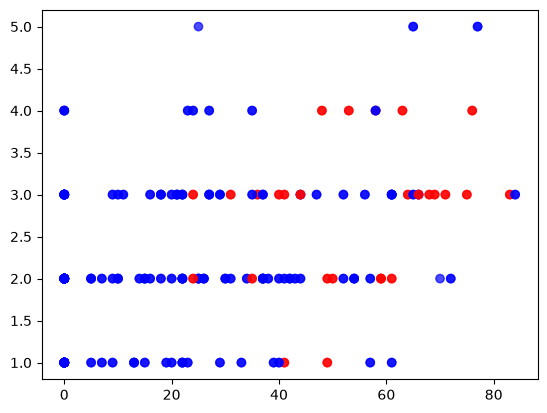

In [53]:
plt.scatter(X['Primer.Par_x'].astype(float), X['Nota.Final_y'].astype(float), c=y['Remontada'], cmap='bwr', alpha=0.7)

(array([ 59.,   0., 111.,   0.,   0.,  91.,   0.,  24.,   0.,   5.]),
 array([1. , 1.4, 1.8, 2.2, 2.6, 3. , 3.4, 3.8, 4.2, 4.6, 5. ]),
 <BarContainer object of 10 artists>)

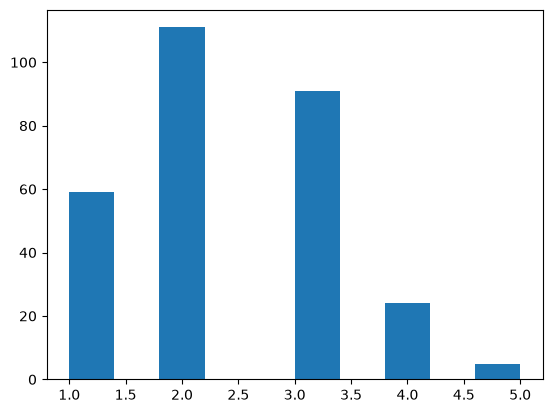

In [54]:
plt.hist(nuevo['Nota.Final_y'].apply(lambda x: x[-1] if isinstance(x, str) else x).astype(float))

In [55]:
nuevo[nuevo['Nota.Final_y'].apply(lambda x: x[-1] if isinstance(x, str) else x).astype(float)==1.0]

,ALUMNO_ID,Cod.Asign_x,Asignatura_x,Cod.Car.Sec_x,Cod.Curso_x,Convocatoria_x,Anho_x,Semestre_x,Doc.Firma_x,Aprobado_x,Anho.Firma_x,Primer.Par_x,Segundo.Par_x,Tercer.Par_x,TPLab._x,Lab._x,Proy._x,Pond.PP_x,Pond.SP_x,Pond.TPLab_x,Pond.Lab_x,Pond.Proy_x,Asis_x,Requisito_x,Firma_x,Primer.Rec_x,Segundo.Rec_x,Nota.Final_x,Archivo_Origen_x,FirmaCalculada_x,Carrera_x,Remontada,Cod.Asign_y,Asignatura_y,Cod.Car.Sec_y,Cod.Curso_y,Convocatoria_y,Anho_y,Semestre_y,Doc.Firma_y,Aprobado_y,Anho.Firma_y,Primer.Par_y,Segundo.Par_y,Tercer.Par_y,TPLab._y,Lab._y,Proy._y,Pond.PP_y,Pond.SP_y,Pond.TPLab_y,Pond.Lab_y,Pond.Proy_y,Asis_y,Requisito_y,Firma_y,Primer.Rec_y,Segundo.Rec_y,Nota.Final_y,Archivo_Origen_y,FirmaCalculada_y,Carrera_y
4,FIUNA_ALUMNO_011332,23031,ELECTRICIDAD Y MAGNETISMO,CIV-PLS23,3,1,2024,2,0,N,0,23,0,0,0,100,0,45,45,0,10,0,1,1,0.00,0,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,CIV,False,23021,OPTICA Y ONDAS,CIV-PLS23,2,1,2025,1,36606,N,2024,67,49,0,0,100,0,45,45,0,10,0,1,1,-1.00,0,0,1F-1,rendimiento_año_2025_ciclo_1_anon.xlsx,62.00,CIV
5,FIUNA_ALUMNO_012334,23031,ELECTRICIDAD Y MAGNETISMO,CIV-PLS23,3,1,2024,2,0,N,0,23,0,0,0,100,0,45,45,0,10,0,1,1,0.00,0,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,CIV,False,23021,OPTICA Y ONDAS,CIV-PLS23,2,1,2025,1,36606,N,2024,67,49,0,0,100,0,45,45,0,10,0,1,1,-1.00,0,0,1F-1,rendimiento_año_2025_ciclo_1_anon.xlsx,62.00,CIV
6,FIUNA_ALUMNO_012170,23031,ELECTRICIDAD Y MAGNETISMO,CIV-PLS23,3,1,2024,2,0,N,0,13,0,0,0,96,0,45,45,0,10,0,1,1,0.00,0,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,CIV,False,23021,OPTICA Y ONDAS,CIV-PLS23,2,1,2025,1,36794,N,2024,0,0,0,0,100,0,45,45,0,10,0,1,1,46.00,0,0,2F-1,rendimiento_año_2025_ciclo_1_anon.xlsx,10.00,CIV
7,FIUNA_ALUMNO_012342,23031,ELECTRICIDAD Y MAGNETISMO,CIV-PLS23,3,1,2024,2,0,N,0,13,0,0,0,96,0,45,45,0,10,0,1,1,0.00,0,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,CIV,False,23021,OPTICA Y ONDAS,CIV-PLS23,2,1,2025,1,36794,N,2024,0,0,0,0,100,0,45,45,0,10,0,1,1,46.00,0,0,2F-1,rendimiento_año_2025_ciclo_1_anon.xlsx,10.00,CIV
10,FIUNA_ALUMNO_012280,23031,ELECTRICIDAD Y MAGNETISMO,ELE-PLS23,3,1,2024,2,0,N,0,13,39,0,0,100,0,45,45,0,10,0,1,1,0.00,41,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,ELE,False,23021,OPTICA Y ONDAS,ELE-PLS23,2,1,2025,1,36794,N,2024,58,49,0,0,100,0,45,45,0,10,0,1,1,-1.00,0,0,1F-1,rendimiento_año_2025_ciclo_1_anon.xlsx,58.00,ELE
11,FIUNA_ALUMNO_012400,23031,ELECTRICIDAD Y MAGNETISMO,ELE-PLS23,3,1,2024,2,0,N,0,13,39,0,0,100,0,45,45,0,10,0,1,1,0.00,41,0,NaN,rendimiento_año_2024_ciclo_2_anon.xlsx,NaN,ELE,False,23021,OPTICA Y ONDAS,ELE-PLS23,2,1,2025,1,36794,N,2024,58,49,0,0,100,0,45,45,0,10,0,1,1,-1.00,0,0,1F-1,rendimiento_año_2025_ciclo_1_anon.xlsx,58.00,ELE
20,FIUNA_ALUMNO_010564,23031,ELECTRICIDAD Y MAGNETISMO,CIV-PLS23,3,1,2025,2,0,N,0,0,0,0,0,32,0,45,45,0,10,0,0,0,3.00,0,0,NaN,rendimiento_año_2025_ciclo_2_anon.xlsx,NaN,CIV,False,23021,OPTICA Y ONDAS,CIV-PLS23,2,1,2025,1,38336,N,2025,51,9,0,0,100,0,45,45,0,10,0,1,1,57.00,53,0,2F-1,rendimiento_año_2025_ciclo_1_anon.xlsx,57.00,CIV
21,FIUNA_ALUMNO_011693,23031,ELECTRICIDAD Y MAGNETISMO,CIV-PLS23,3,1,2025,2,0,N,0,0,0,0,0,32,0,45,45,0,10,0,0,0,3.00,0,0,NaN,rendimiento_año_2025_ciclo_2_anon.xlsx,NaN,CIV,False,23021,OPTICA Y ONDAS,CIV-PLS23,2,1,2025,1,38336,N,2025,51,9,0,0,100,0,45,45,0,10,0,1,1,57.00,53,0,2F-1,rendimiento_año_2025_ciclo_1_anon.xlsx,57.00,CIV
26,FIUNA_ALUMNO_010885,23031,ELECTRICIDAD Y MAGNETISMO,CIV-PLS23,3,1,2025,2,38723,N,2025,57,54,0,0,100,0,45,45,0,10,0,1,1,60.00,0,0,NaN,rendimiento_año_2025_ciclo_2_anon.xlsx,NaN,CIV,False,23021,OPTICA Y ONDAS,CIV-PLS23,2,1,2025,1,38009,N,2025,64,47,0,0,100,0,45,45,0,10,0,1,1,60.00,0,0,1F-1,rendimiento_año_2025_ciclo_1_anon.xlsx,60.00,CIV
27,FIUNA_ALUMNO_011265,23031,ELECTRICIDAD Y MAGNETISMO,CIV-PLS23,3,1,2025,2,38723,N,2025,57,54,0,0,100,0,45,45,0,10,0,1,1,60.00,0,0,NaN,rendimiento_año_2025_ciclo_2_anon.xlsx,NaN,CIV,False,23021,OPTICA Y ONDAS,CIV-PLS23,2,1,2025,1,38009,N,2025,64,47,0,0,100,0,45,45,0,10,0,1,1,60.00,0,0,1F-

In [56]:
NoNulos=X.isnull().any(axis=1)
Xl=X[np.logical_not(NoNulos)]
yl=y[np.logical_not(NoNulos)]

In [58]:
modelo=LogisticRegression(class_weight='balanced', random_state=42)
modelo.fit(Xl.values,yl.values)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default

In [59]:
modelo.coef_    

array([[0.21710158, 0.07067229]])

In [60]:
ypre=modelo.predict(Xl.values)

In [61]:
confusion_matrix(yl.values, ypre)

array([[184,  52],
       [ 12,  42]])

In [63]:
print(classification_report(yl.values, ypre))  

              precision    recall  f1-score   support

       False       0.94      0.78      0.85       236
        True       0.45      0.78      0.57        54

    accuracy                           0.78       290
   macro avg       0.69      0.78      0.71       290
weighted avg       0.85      0.78      0.80       290

